# Inference Recorder Review
This notebook is focused on visually checking what the inference recorder is saving.
It is intentionally exploratory and tolerant to partial runs.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.notebooks.review_utils import (
    PROJECT_ROOT,
    discover_recorder_payloads,
    list_recorder_files,
    extract_decoder_deformable_attention,
    load_recorder_payload,
    resolve_image_bank_path,
    payload_summary_frame,
    activation_inventory_frame,
    decoder_attention_summary_frame,
    aggregate_batch_decoder_attention_query_profiles,
    compute_batch_decoder_attention_query_profiles,
    compute_decoder_attention_query_profiles,
    plot_scanpath_overview,
    plot_attention_heatmap,
    plot_sampling_locations,
    plot_batch_decoder_attention_query_profiles,
    plot_decoder_deformable_attention_overlay,
    plot_decoder_attention_query_profiles,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)
PROJECT_ROOT

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath')

In [2]:
all_pt_files = list_recorder_files()
# display(all_pt_files.head(20))

recorder_files = discover_recorder_payloads(limit=50)
# display(recorder_files)

if recorder_files.empty:
    print('No inference-recorder payloads were found yet. Once a run produces *.pt payloads, re-run this notebook.')

In [3]:
selected_path = None
if not recorder_files.empty:
    selected_path = PROJECT_ROOT / recorder_files.iloc[0]['file']
selected_path

WindowsPath('C:/Users/ulloa/Miooooo/Master/thesis/projectes/From-Noisy-Eye-Tracking-To-Scanpath/outputs/outputs/2026-03-18/12-20-06/inference_records/train_epoch_0120_batch_00163_step_019798_Combined.pt')

## Decoder Deformable Attention Overlay
This section is focused on `decoder.#.second_cross_attn` only.
The origin is reconstructed from teacher-forced fixation coordinates, so query `0` starts at `(0.5, 0.5)` and later queries start at the previous ground-truth fixation.
The `eye_decoder.#.cross_attn` branch is intentionally left out for this iteration.

In [4]:
external_record_dir = Path(r'outputs\outputs\2026-03-18\12-20-06\inference_records')
external_candidates = sorted(external_record_dir.glob('*.pt')) if external_record_dir.exists() else []
payload_path = external_candidates[-1] if external_candidates else selected_path
sample_index = 1
decoder_layer = 3
query_index = 4
aggregate_heads = False
head_index = None
image_bank_path = None

payload_path

WindowsPath('outputs/outputs/2026-03-18/12-20-06/inference_records/val_epoch_0120_batch_00053_Combined.pt')

In [5]:
payload = None
if payload_path is not None:
    payload = load_recorder_payload(payload_path)
    # display(payload.get('metadata', {}))
    # display(payload_summary_frame(payload))
    try:
        resolved_image_bank_path = resolve_image_bank_path(payload_path=payload_path, image_bank_path=image_bank_path)
        print('image_bank_path =', resolved_image_bank_path)
    except FileNotFoundError as exc:
        resolved_image_bank_path = None
        print(exc)

image_bank_path = C:\Users\ulloa\Miooooo\Master\thesis\projectes\From-Noisy-Eye-Tracking-To-Scanpath\data\Coco FreeView\all_images_256.pth


In [6]:
for key, values in (list(payload["activations"].values())[-1]).items():
    print(key, type(values))

sampling_offsets <class 'list'>
attention_weights <class 'list'>
sampling_locations <class 'list'>
reference_points <class 'list'>


In [7]:
len((list(list(payload["activations"].values())[-1].values())[0]))

14

In [8]:
decoder_attention_info = None
if payload is not None:
    decoder_attention_info = extract_decoder_deformable_attention(
        payload,
        sample_index=sample_index,
        decoder_layer=decoder_layer,
        query_index=query_index,
        aggregate_heads=aggregate_heads,
        head_index=head_index,
    )
    # display({
    #     'module_name': decoder_attention_info['module_name'],
    #     'query_count': decoder_attention_info['query_count'],
    #     'num_heads': decoder_attention_info['num_heads'],
    #     'num_points': decoder_attention_info['num_points'],
    #     'valid_fixation_count': decoder_attention_info['valid_fixation_count'],
    #     'is_terminal_or_padded': decoder_attention_info['is_terminal_or_padded'],
    #     'selected_head_index': decoder_attention_info['selected_head_index'],
    # })
    # display(decoder_attention_summary_frame(
    #     payload,
    #     sample_index=sample_index,
    #     decoder_layer=decoder_layer,
    #     query_index=query_index,
    #     aggregate_heads=aggregate_heads,
    #     head_index=head_index,
    # ))

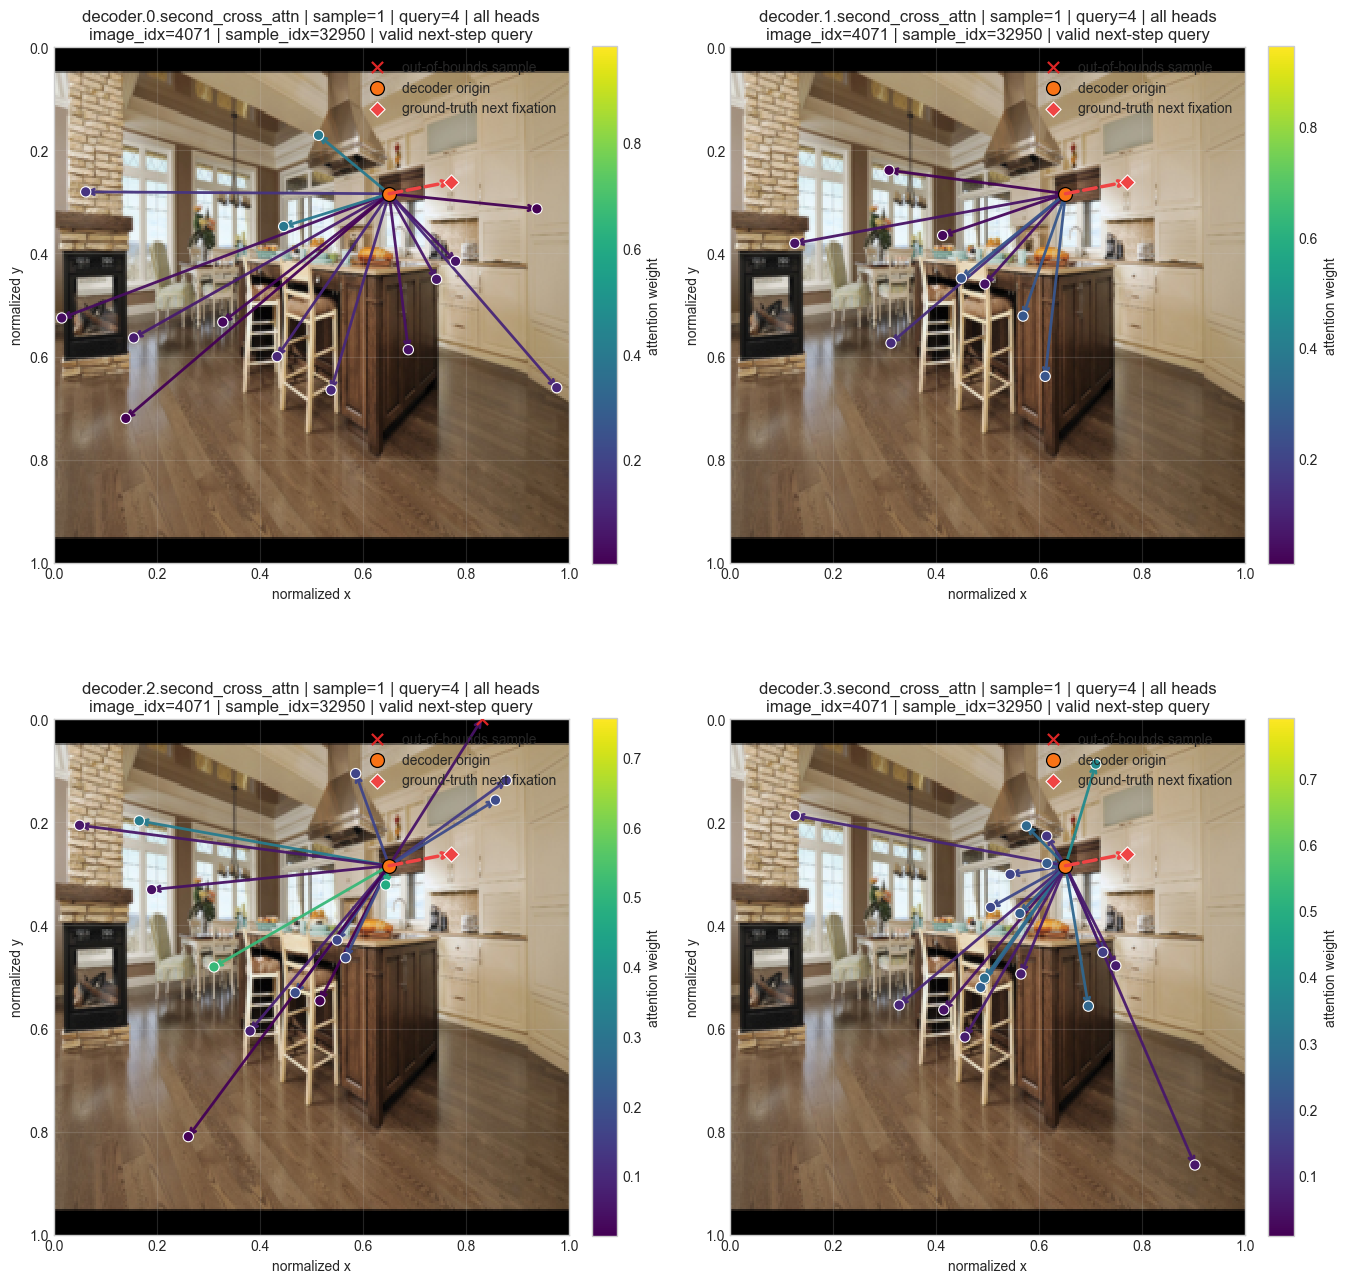

In [9]:
if payload is not None:
    fig, ax = plt.subplots(2,2,figsize = (16,16))
    item_count = 0
    for i in range(2):
        for j in range(2):

            plot_decoder_deformable_attention_overlay(
                payload,
                ax=ax[i,j],
                sample_index=sample_index,
                decoder_layer=item_count,
                query_index=query_index,
                aggregate_heads=aggregate_heads,
                head_index=head_index,
                payload_path=payload_path,
                image_bank_path=image_bank_path,
            )
            item_count += 1

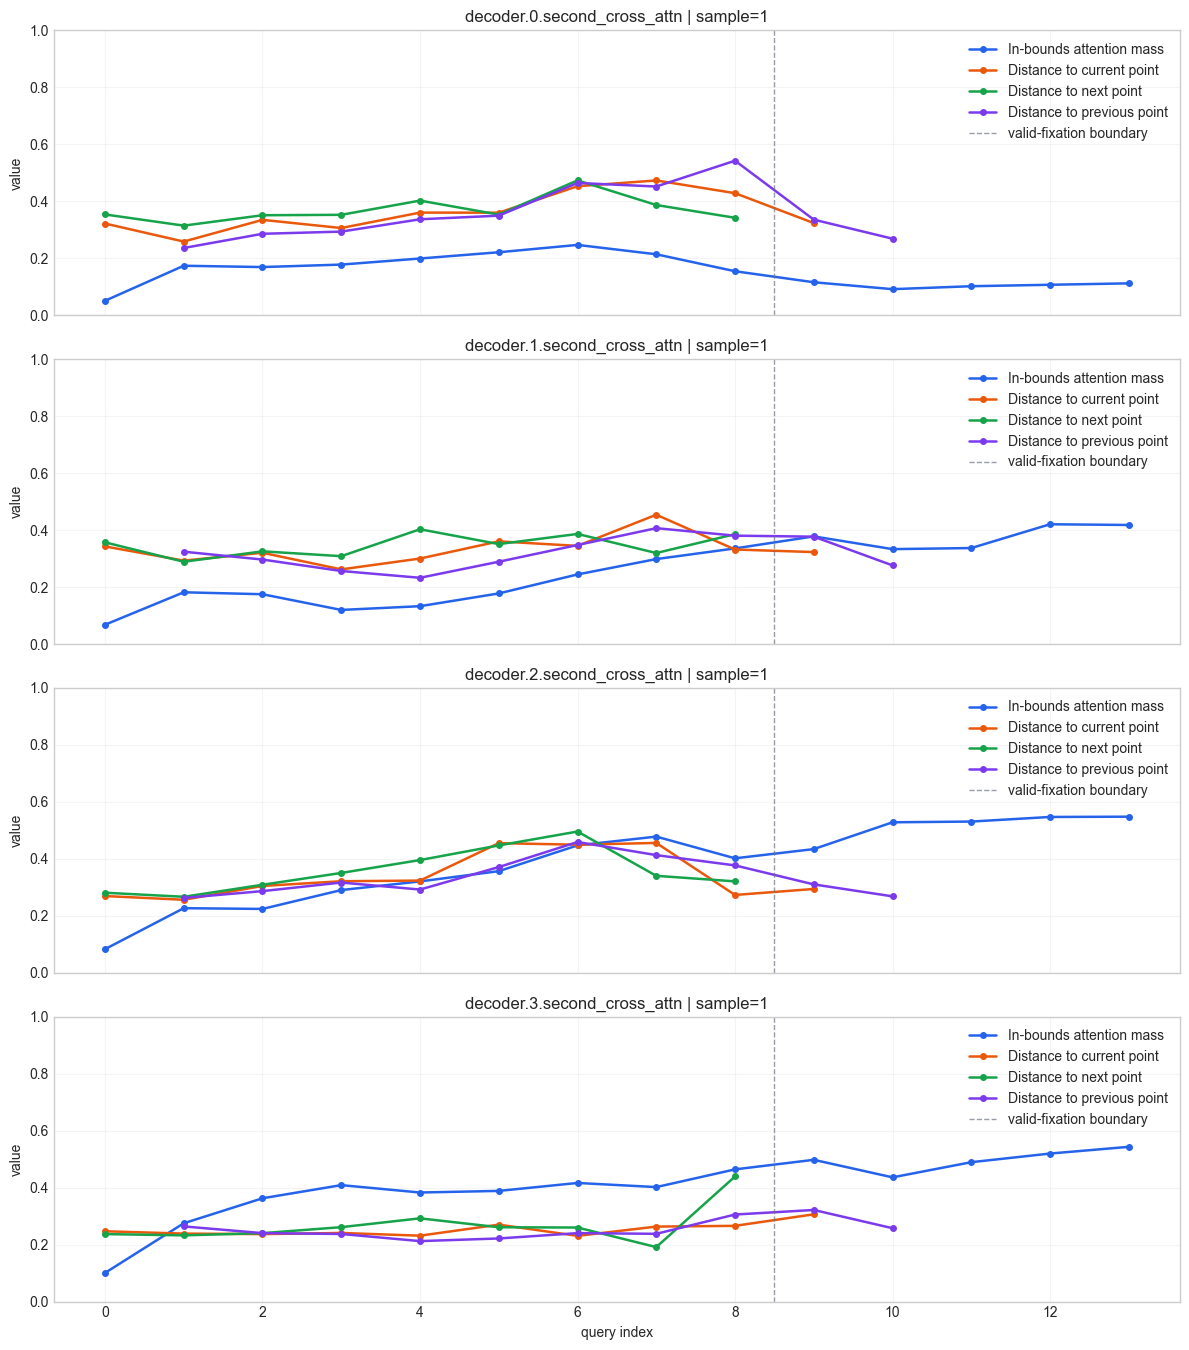

In [10]:
if payload is not None:
    decoder_query_profiles = plot_decoder_attention_query_profiles(
        payload,
        sample_index=sample_index,
    )
    # display(decoder_query_profiles)


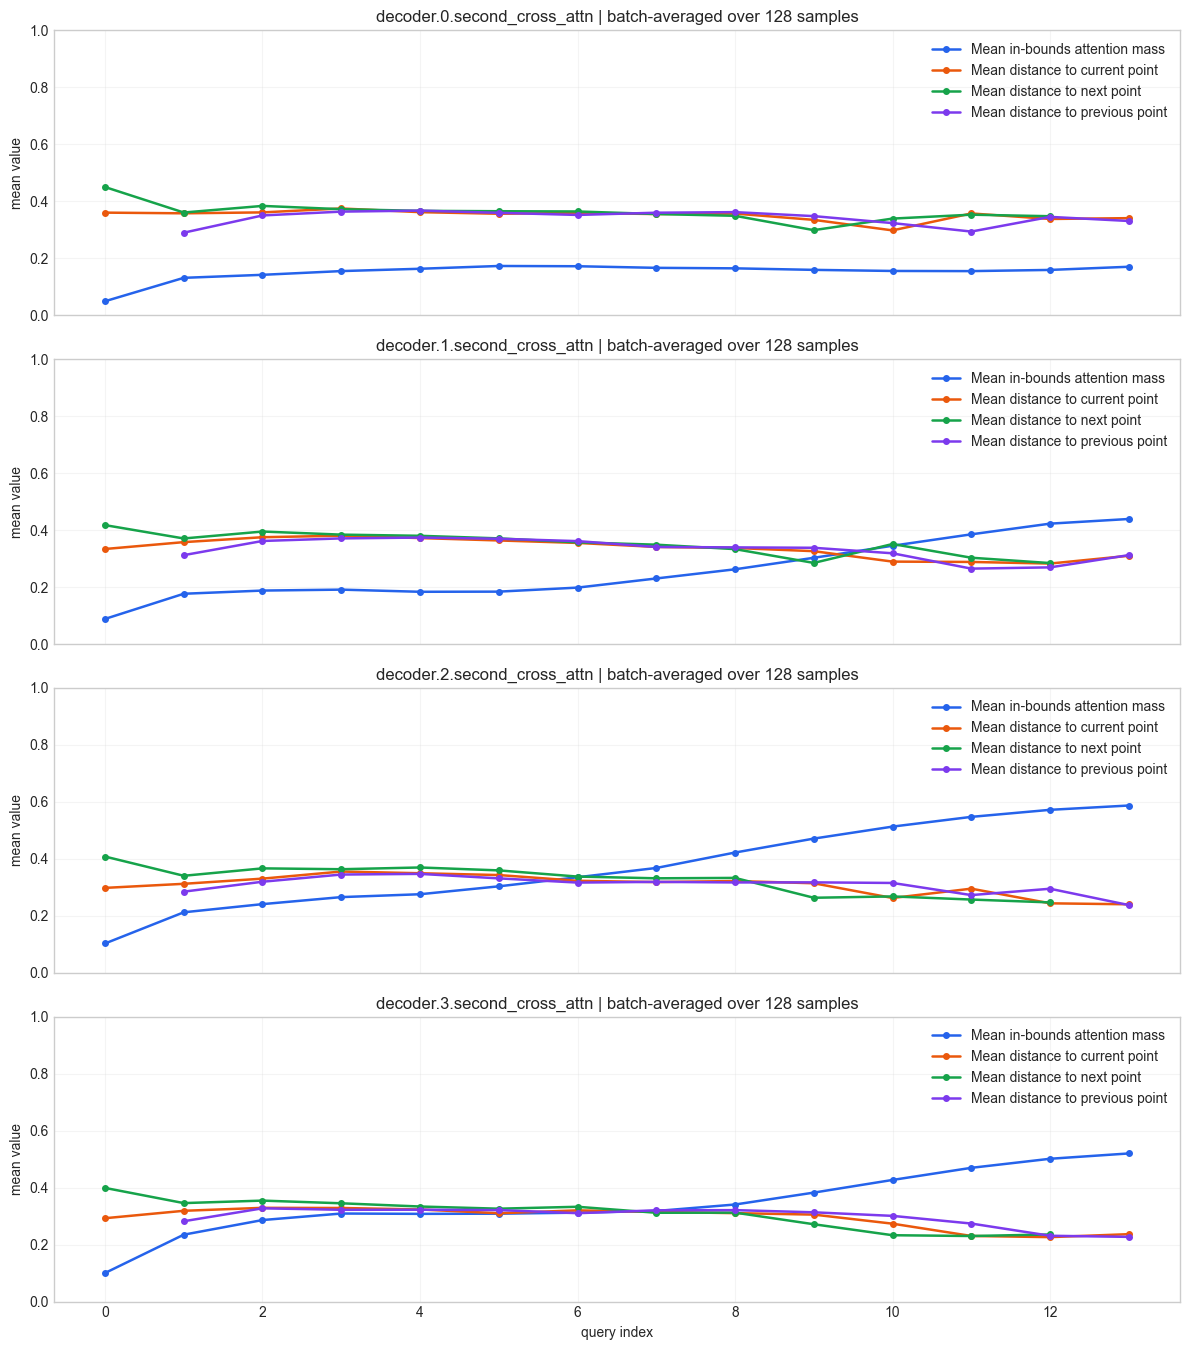

In [11]:
if payload is not None:
    batch_decoder_query_profiles = plot_batch_decoder_attention_query_profiles(payload)
    # display(batch_decoder_query_profiles)


In [12]:
#if payload is not None:
    # display(activation_inventory_frame(payload).sort_values(['module', 'activation']).reset_index(drop=True))

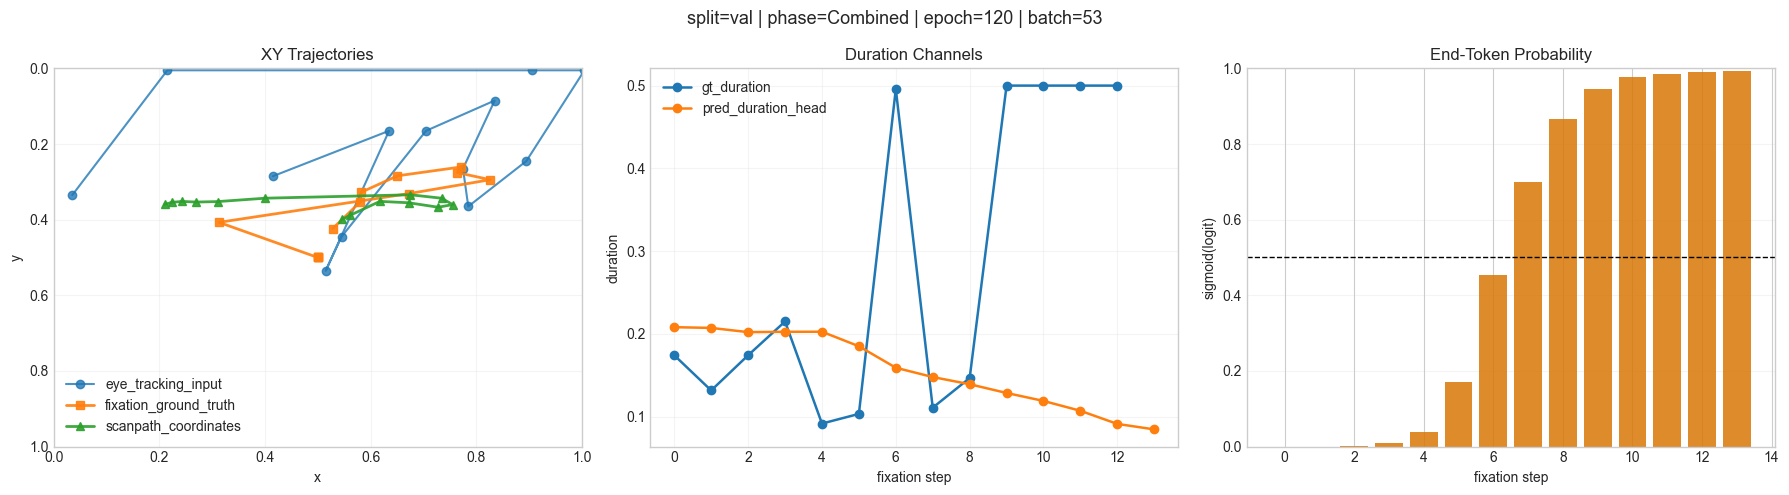

In [13]:
if payload is not None:
    plot_scanpath_overview(payload, sample_index=sample_index)

In [119]:
from src.data.datasets import FreeViewInMemory
data = FreeViewInMemory()

In [120]:
data.data_store.keys()

dict_keys(['down_gaze', 'filtered_idx', 'fixation_mask', 'fixations', 'gaze'])

In [101]:
payload["data"].keys()

dict_keys(['sample_idx', 'image_idx', 'eye_tracking_input', 'fixation_ground_truth'])

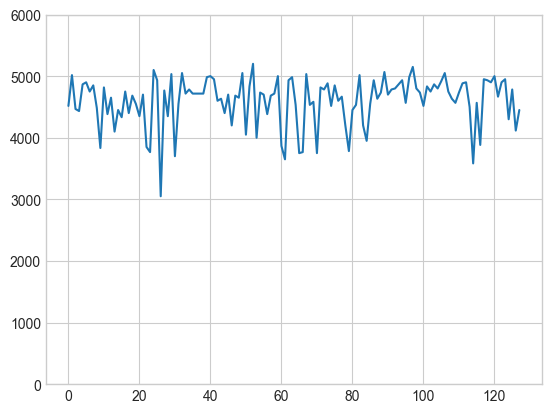

In [132]:
import torch
idx = payload["data"]["sample_idx"]
fixations_gt:torch.Tensor = payload["data"]["fixation_ground_truth"]
masks = data.data_store["fixation_mask"][idx]


plt.plot([len(item)*(1000/60) for item in masks])
plt.ylim(0,6000)
plt.show()

In [ ]:
def compute_fixation_mask(fixation):
    return torch.all(fixation == 0.5,dim = -1)

eps = 2e-05
f_off_size = []
for i in range(idx.shape[0]):
    data_idx = idx[i]
    item = data.data_store['fixations'][data_idx].reshape((3, -1)).copy()[:2]
    item[0,:] = item[0,:]/512
    item[1,:] = item[1,:]/320
    
    padding_mask = compute_fixation_mask(fixations_gt[i])
    item_gt = fixations_gt[i][:,:2].T.numpy()[:,padding_mask.logical_not()]
    not_zero = True
    best_idx = -1
    best_diff = 1000
    second_best_diff = 1000
    for j in range(item.shape[1] - item_gt.shape[1]):
        
        diff = (np.abs(item[:,j:item_gt.shape[1] + j] - item_gt)).sum()
        
        if diff < eps:
            not_zero = False
        if diff < best_diff:
            second_best_diff = best_diff
            best_diff = diff
            best_idx = j
    if not_zero:
        print("no match: ", i)
    else:
        if second_best_diff < eps:
            print("MATCH NOT UNIQUE")
            print("best_idx: ",best_idx)
            print("best_diff: ",best_diff)
            print("second_best_diff: ",second_best_diff)
    f_off_size.append({
        "offset":j,
        "size":item_gt.shape[1]
    })

    
    


[-1, 114, -1, 240, 272, -1, 138, 130, 170, -1, -1, -1, -1, 132, 159, -1, 136, -1, -1, -1, 107, -1, -1, -1, -1, -1, 167, -1, 232, -1, 72, -1, -1, 122, -1, -1, -1, 245, 135, -1, -1, -1, 264, 256, -1, -1, -1, 143, 260, -1, -1, -1, 165, 112, -1, -1, 118, 120, 262, -1, 209, -1, -1, 153, 136, -1, -1, -1, -1, -1, -1, -1, 271, -1, -1, -1, 260, -1, -1, -1, -1, -1, -1, -1, 90, -1, 142, 247, 122, 154, -1, 126, -1, 114, -1, 114, -1, 288, -1, -1, 135, 188, -1, 259, -1, 145, -1, -1, -1, 262, 143, -1, -1, -1, 78, 245, -1, 271, -1, -1, -1, -1, 283, 235, -1, -1, -1, -1]


In [91]:
payload["data"]["eye_tracking_input"][0,:,2]*2600

tensor([   0.0000,  200.0000,  399.9999,  599.9999,  799.9999,  999.9999,
        1200.0000, 1400.0001, 1600.0000, 1800.0000, 2000.0000, 2200.0000,
        2400.0000])

In [237]:
from src.preprocess.simulation import downsampling_index
import numpy as np
import random
# idx = random.randint(0,len(masks))
idx = 0
mask = masks[idx]
print("index: ", idx)
print("len: ", len(mask))

def downsample_mask(mask):
    fake_gaze = np.zeros((3,len(mask)))
    fake_gaze[2,:] = np.arange(len(mask))*1000/60
    d_idx = downsampling_index(fake_gaze)[0]
    return d_idx
d_idx_list = []
for i in range(masks.shape[0]):    
    d_idx_list.append(downsample_mask(masks[i]))

d_mask = mask[d_idx_list[idx]]
print("d_len: ", len(d_mask))


index:  0
len:  271
d_len:  23


C:\Users\ulloa\AppData\Local\Temp\ipykernel_20592\881548315.py:42: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


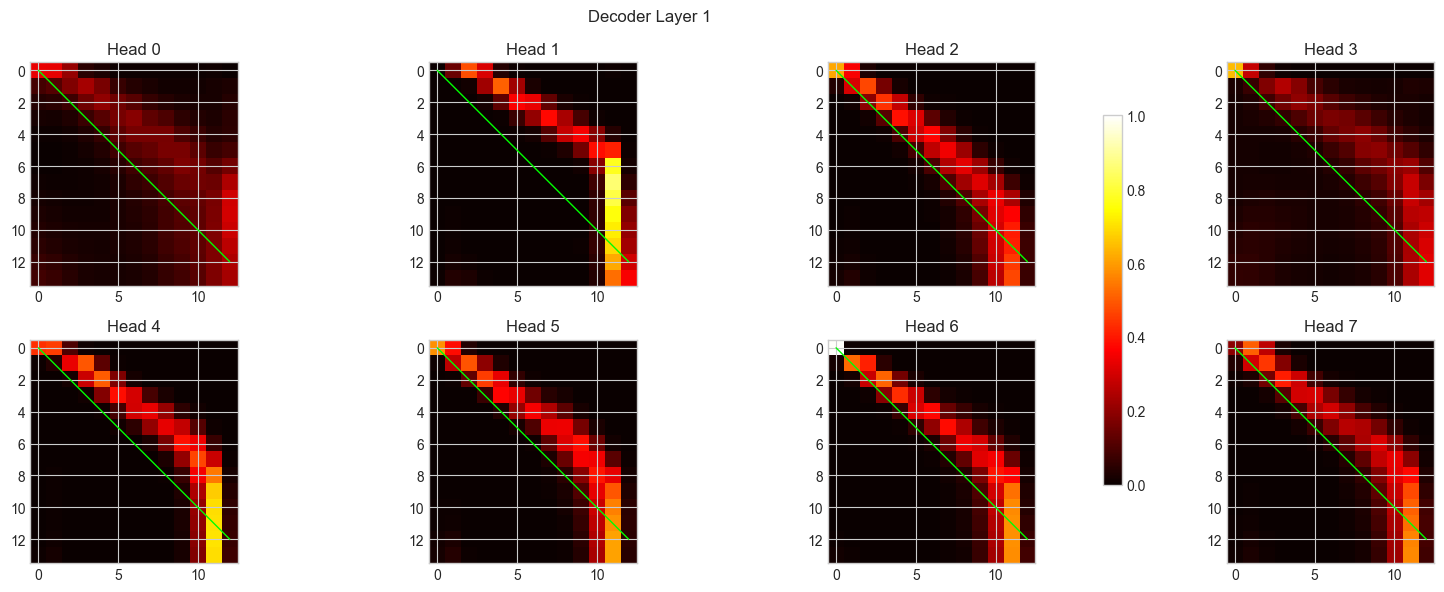

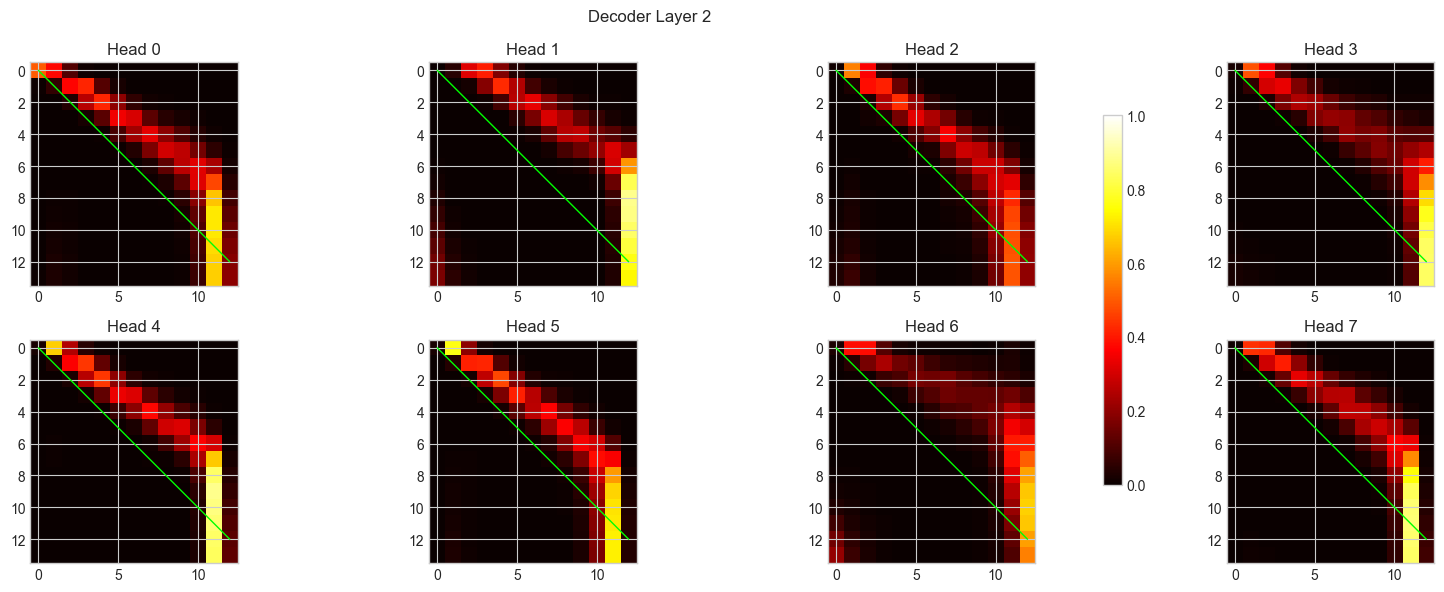

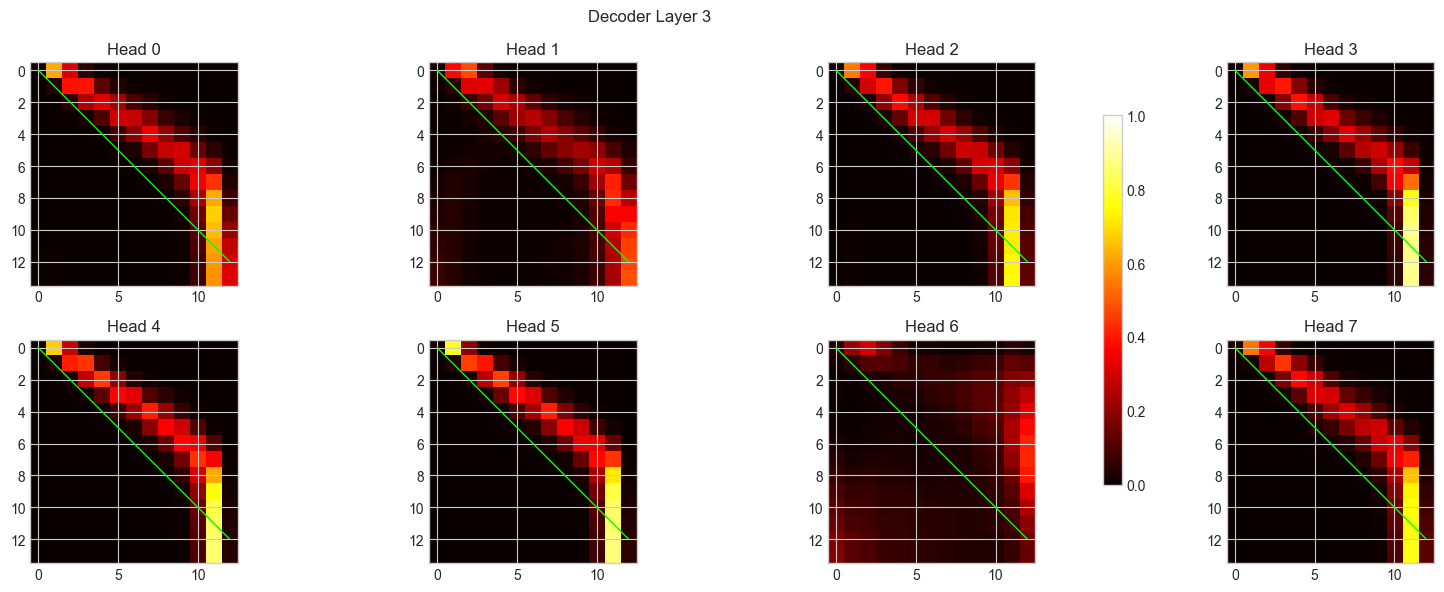

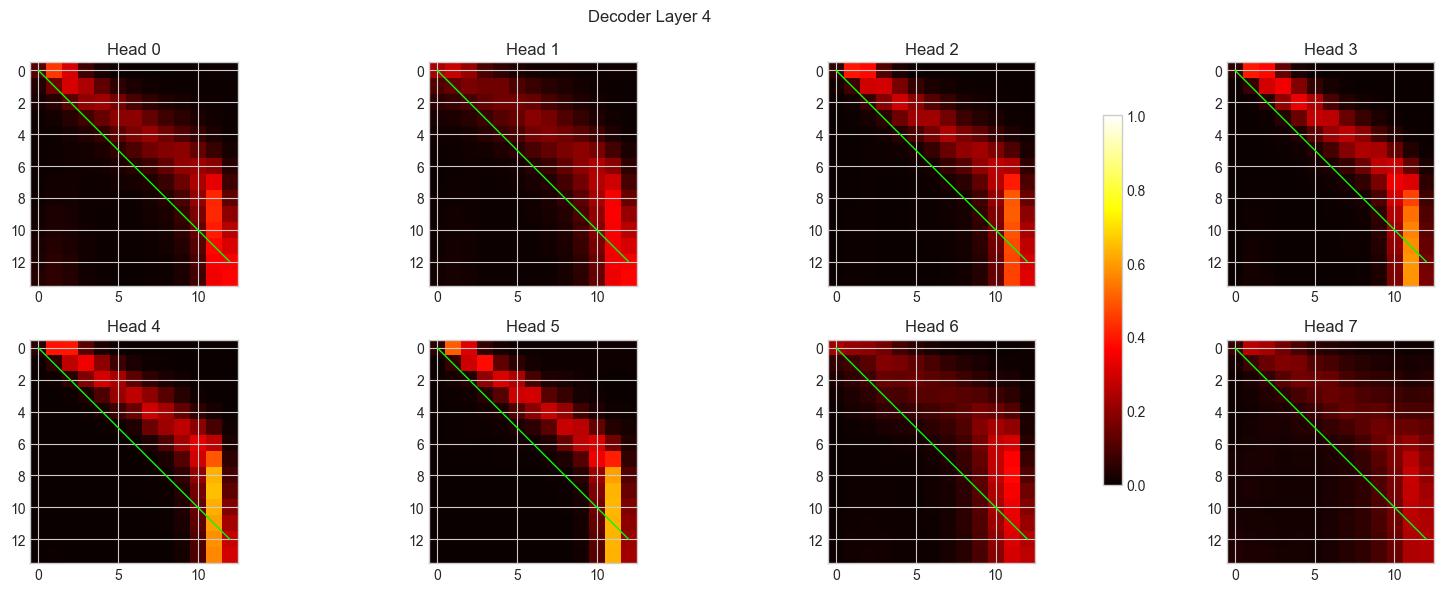

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import torch
import random
mean_over_batch = True
show_align = False
index = 0
attentions = []
for key, values in payload["activations"].items():
    if "first_cross_attn" in key:
        item = values["attention_weights"][-1]
        attentions.append(item)

for k in range(4):
    if show_align:
        fig, axis = plt.subplots(2, 8, figsize=(20, 6))
    else:
        fig, axis = plt.subplots(2, 4, figsize=(20, 6))
    layer = attentions[k]

    # Compute all heads first so they share the same normalization
    heads = []
    for item_count in range(8):
        if mean_over_batch:
            head = layer[:, item_count, :, :].mean(axis=0)
        else:
            head = layer[index, item_count, :, :]
        heads.append(head.cpu().numpy())
    
    norm = colors.Normalize(vmin=0, vmax=1)

    fig.suptitle(f"Decoder Layer {k + 1}")

    item_count = 0
    im = None
    for i in range(2):
        for j in range(4):
            if show_align:
                im = axis[i, j*2].imshow(heads[item_count], cmap="hot", norm=norm)
                im = axis[i, j*2].imshow(heads[item_count], cmap="hot", norm=norm)

            sizex = heads[item_count].shape[0]
            sizey = heads[item_count].shape[1]
            min_size = min(sizey - 1,sizex - 1)
            axis[i, j].plot([0, min_size], [0, min_size], color="lime", linewidth=1)
            axis[i, j].set_title(f"Head {item_count}")
            item_count += 1

    # One shared colorbar for the whole figure
    fig.colorbar(im, ax=axis, shrink=0.8)
    plt.tight_layout()
    plt.show()

## Notes
- `data` comes from `InferenceRecorder.record_batch` and currently includes indices plus input/target tensors when present.
- `outputs` includes `denoise`, `coord`, `dur`, `reg`, and `cls` under more descriptive names.
- `activations` currently come from attention modules in `blocks.py`, mainly cross-attention weights and deformable-attention sampling tensors.